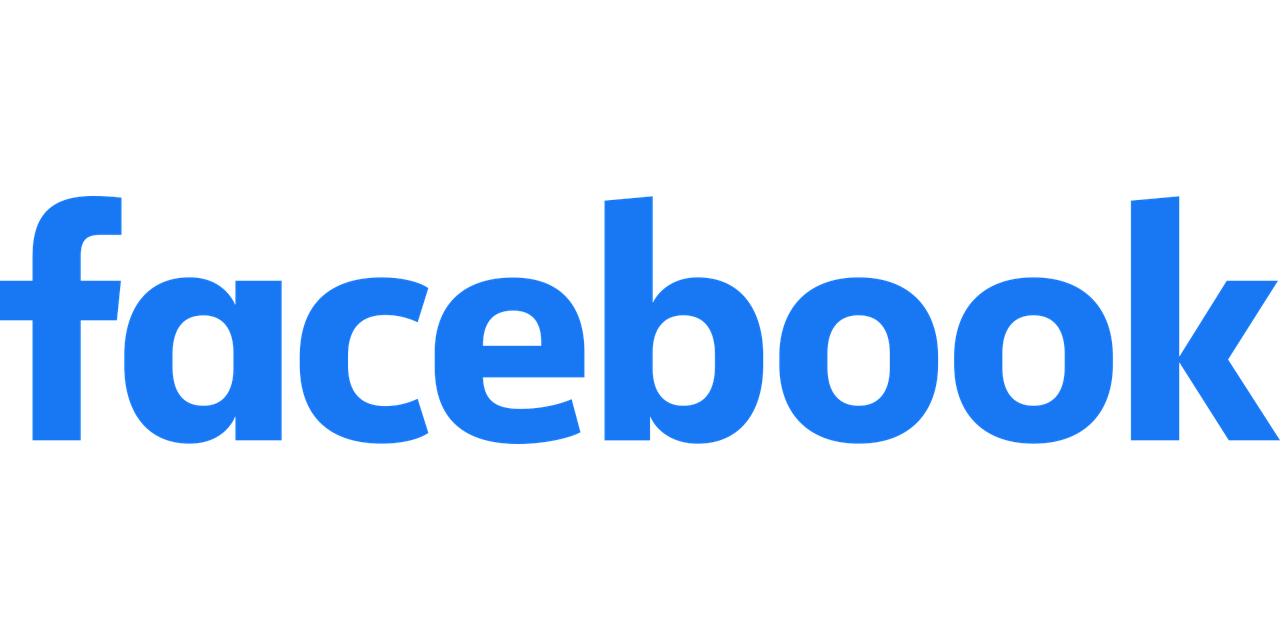

## Структура работы
#### Исследовательский анализ (EDA)
#### Анализ категориальных признаков 
#### Анализ числовых признаков 
#### Проверка допущений линейной модели 
#### Feature engeeniring
#### Pipeline
#### Results
#### Confusion matrix, classification report

## Цель
#### Цель классификация(Нажмет человек на рекламу или нет)

### Facebook, синтетический датасет, созданный преподавателями одного из онлайн‑курсов по машинному обучению, на нём демонстрируют базовые приёмы предобработки и классификации: он имитирует пользователей (их время на сайте, доход, страну и т. д.) и случайным образом генерирует целевую метку «Clicked». У него нет реального «бэк‑энда»

## Переменные
#### Names, emails, Country, time spent on Site, Salary, Clicked

### EDA

In [661]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
import scipy.stats as stats
from sklearn.naive_bayes import GaussianNB
from sklearn.feature_selection import mutual_info_classif, SelectKBest
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.linear_model import  LinearRegression, LogisticRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.metrics import mean_squared_error
from yellowbrick.regressor import ResidualsPlot
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, accuracy_score, precision_score, f1_score, recall_score, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.compose import ColumnTransformer
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.ensemble import StackingClassifier
from sklearn.metrics import log_loss
import warnings
from sklearn.exceptions import FitFailedWarning
warnings.filterwarnings('ignore', category=FitFailedWarning)

In [662]:
df = pd.read_csv('../Facebook_Ads_2.csv', encoding='ISO-8859-1')

In [663]:
df.shape

(499, 6)

In [664]:
df.head(20)

,Names,emails,Country,Time Spent on Site,Salary,Clicked
0,Martina Avila,cubilia.Curae.Phasellus@quisaccumsanconvallis.edu,Bulgaria,25.649648,55330.06006,0
1,Harlan Barnes,eu.dolor@diam.co.uk,Belize,32.456107,79049.07674,1
2,Naomi Rodriquez,vulputate.mauris.sagittis@ametconsectetueradip...,Algeria,20.945978,41098.60826,0
3,Jade Cunningham,malesuada@dignissim.com,Cook Islands,54.039325,37143.35536,1
4,Cedric Leach,felis.ullamcorper.viverra@egetmollislectus.net,Brazil,34.249729,37355.11276,0
5,Carla Hester,mi@Aliquamerat.edu,Liberia,52.009946,80642.65222,1
6,Griffin Rivera,vehicula@at.co.uk,Syria,42.881370,61908.39815,1
7,Orli Casey,nunc.est.mollis@Suspendissetristiqueneque.co.uk,Czech Republic,25.676920,29851.41153,0
8,Marny Obrien,Phasellus@sedsemegestas.org,Armenia,40.698233,34281.11878,1
9,Rhonda Chavez,nec@nuncest.com,Somalia,29.687362,41098.87881,0


In [665]:
df.describe()

,Time Spent on Site,Salary,Clicked
count,499.000000,499.000000,499.000000
mean,32.920178,52896.992469,0.501002
std,9.103455,18989.183150,0.500501
min,5.000000,20.000000,0.000000
25%,26.425044,38888.117260,0.000000
50%,33.196067,52840.913110,1.000000
75%,39.114995,65837.288190,1.000000
max,60.000000,100000.000000,1.000000


In [666]:
df.isnull().sum()

Names                 0
emails                0
Country               0
Time Spent on Site    0
Salary                0
Clicked               0
dtype: int64

In [667]:
click =df[df['Clicked']==1]
no_click = df[df['Clicked']==0]

In [668]:
print('Total = ', len(df))
print('Number of customers who clicked on ad = ', len(click))
print('Percentage clicked = ', 1.* len(click) / len(df)*100.0, '%')
print('Did not click = ', len(no_click))
print('Percentage who did not click = ', 1.*len(no_click) / len(df) * 100.0, '%')

Total =  499
Number of customers who clicked on ad =  250
Percentage clicked =  50.1002004008016 %
Did not click =  249
Percentage who did not click =  49.899799599198396 %


In [669]:
df['Clicked'].value_counts(normalize=True)

Clicked
1    0.501002
0    0.498998
Name: proportion, dtype: float64

In [670]:
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
print(categorical_cols)

['Names', 'emails', 'Country']


In [671]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(numerical_cols)

['Time Spent on Site', 'Salary', 'Clicked']


In [672]:
discrete_cols = [col for col in numerical_cols if df[col].nunique() < 20]
continuous_cols = [col for col in numerical_cols if col not in discrete_cols]
print(discrete_cols)
print(continuous_cols)

['Clicked']
['Time Spent on Site', 'Salary']


## Categorical

In [673]:
df['Names'].value_counts()

Names
Seth               2
Walter             2
Edward             1
Laurel             1
Igor               1
                  ..
Quin Smith         1
Tatum Moon         1
Sharon Sharpe      1
Thomas Williams    1
Heather            1
Name: count, Length: 497, dtype: int64

In [674]:
df['Names'].nunique()

497

In [675]:
df['emails'].value_counts()

emails
Quisque.varius@arcuVivamussit.net                    1
cubilia.Curae.Phasellus@quisaccumsanconvallis.edu    1
eu.dolor@diam.co.uk                                  1
orci.adipiscing@penatibuset.com                      1
erat.Etiam@elementum.org                             1
                                                    ..
nunc.est.mollis@Suspendissetristiqueneque.co.uk      1
vehicula@at.co.uk                                    1
mi@Aliquamerat.edu                                   1
felis.ullamcorper.viverra@egetmollislectus.net       1
malesuada@dignissim.com                              1
Name: count, Length: 499, dtype: int64

In [676]:
df['Country'].value_counts()

Country
Israel                                          6
Bolivia                                         6
Mauritania                                      6
Greenland                                       5
Kyrgyzstan                                      5
                                               ..
South Sudan                                     1
Ukraine                                         1
New Zealand                                     1
Saint Helena, Ascension and Tristan da Cunha    1
Malaysia                                        1
Name: count, Length: 210, dtype: int64

In [677]:
df['Country'].nunique()

210

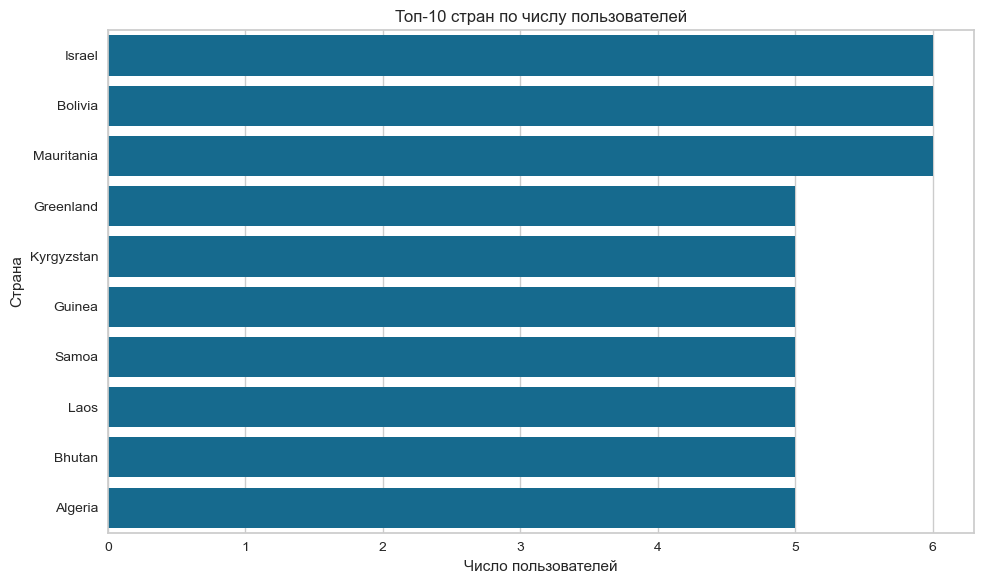

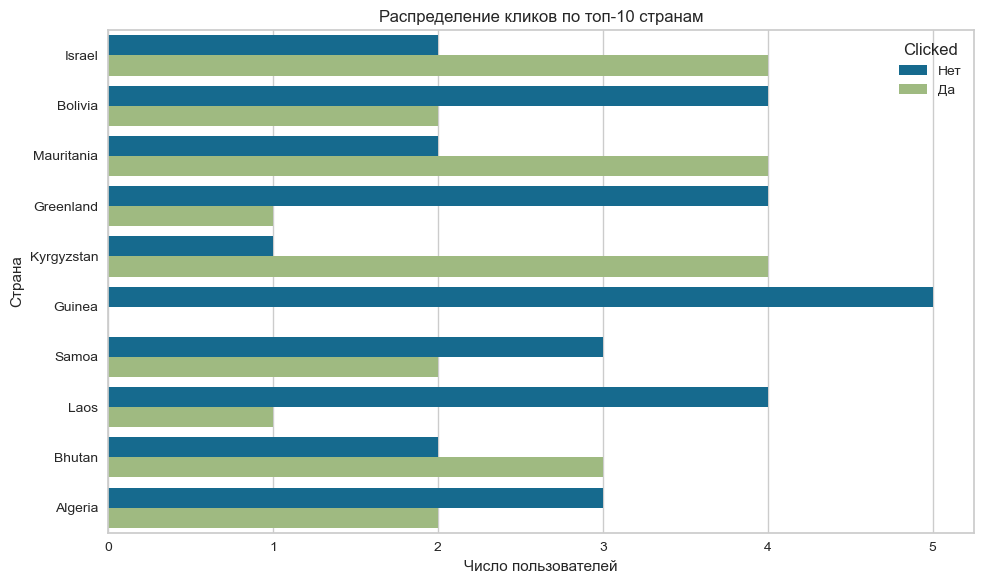

In [678]:
country_counts = df['Country'].value_counts()
top_countries = country_counts.head(10)

plt.figure(figsize=(10, 6))
sns.barplot(y=top_countries.index, x=top_countries.values)
plt.title('Топ-10 стран по числу пользователей')
plt.xlabel('Число пользователей')
plt.ylabel('Страна')
plt.tight_layout()
plt.show()

# Анализ кликов по странам 
top_countries_list = top_countries.index.tolist()
df_top_countries = df[df['Country'].isin(top_countries_list)]

plt.figure(figsize=(10, 6))
sns.countplot(
    data=df_top_countries,
    y='Country',
    hue='Clicked',
    order=top_countries_list)
    
plt.title('Распределение кликов по топ-10 странам')
plt.xlabel('Число пользователей')
plt.ylabel('Страна')
plt.legend(title='Clicked', labels=['Нет', 'Да'])
plt.tight_layout()
plt.show()

## Numerical

In [679]:
df['Time Spent on Site'].value_counts()

Time Spent on Site
32.386148    1
25.649648    1
32.456107    1
37.674058    1
22.439488    1
            ..
25.676920    1
42.881370    1
52.009946    1
34.249729    1
54.039325    1
Name: count, Length: 499, dtype: int64

In [680]:
df['Salary'].value_counts()

Salary
74331.35442    1
55330.06006    1
79049.07674    1
62034.48602    1
35917.84819    1
              ..
29851.41153    1
61908.39815    1
80642.65222    1
37355.11276    1
37143.35536    1
Name: count, Length: 499, dtype: int64

In [681]:
def diagnostic_plots(df, variable):
    plt.figure(figsize = (16, 4))
    # Histogram
    plt.subplot(1, 3, 1)
    sns.histplot(df[variable], bins=30)
    plt.title('Histogram')
    # Q-Q plot
    plt.subplot(1, 3, 2)
    stats.probplot(df[variable], dist='norm', plot=plt)
    plt.ylabel('Quantiles')
    # Boxplot
    plt.subplot(1, 3, 3)
    sns.boxplot(y = df[variable])
    plt.title('Boxplot')
    plt.show()

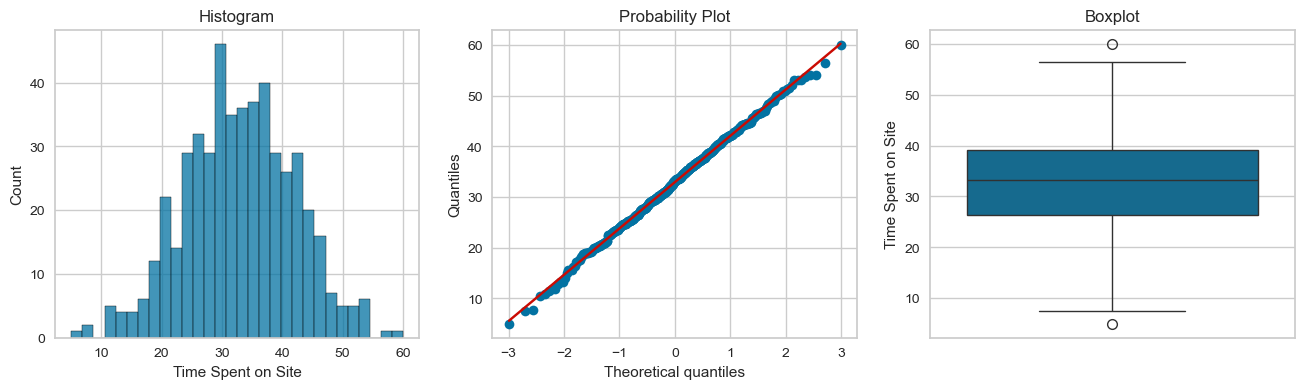

In [682]:
diagnostic_plots(df, 'Time Spent on Site')

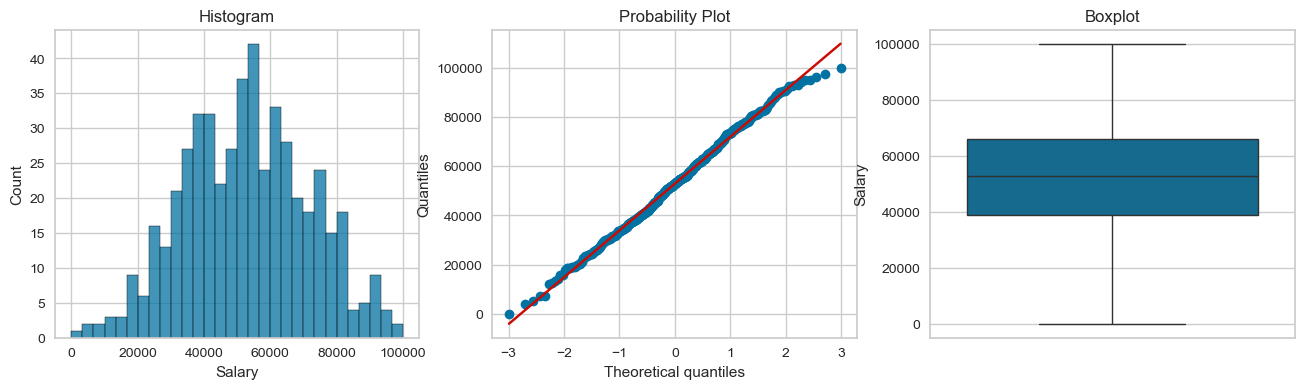

In [683]:
diagnostic_plots(df, 'Salary')

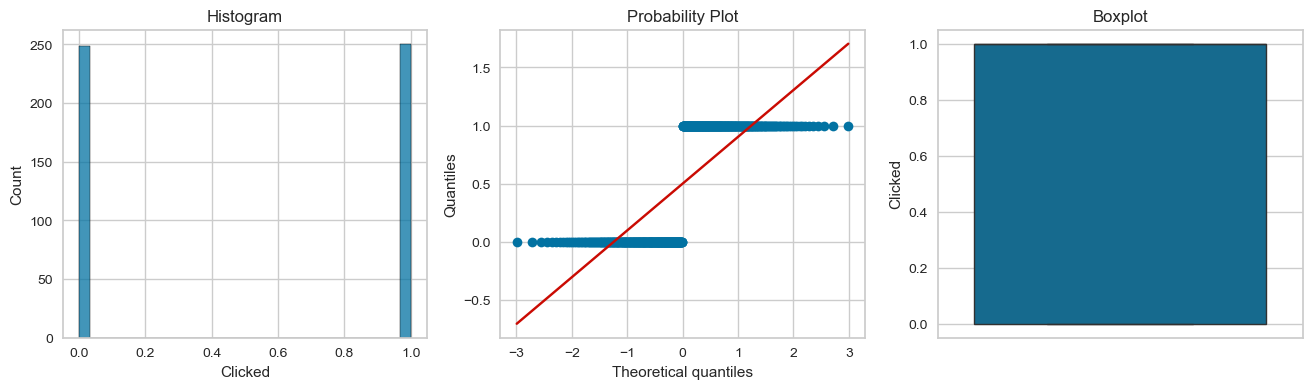

In [684]:
diagnostic_plots(df, 'Clicked')

In [685]:
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    print(f"Выбросы в {col}: {outliers} точек")

Выбросы в Time Spent on Site: 2 точек
Выбросы в Salary: 0 точек
Выбросы в Clicked: 0 точек


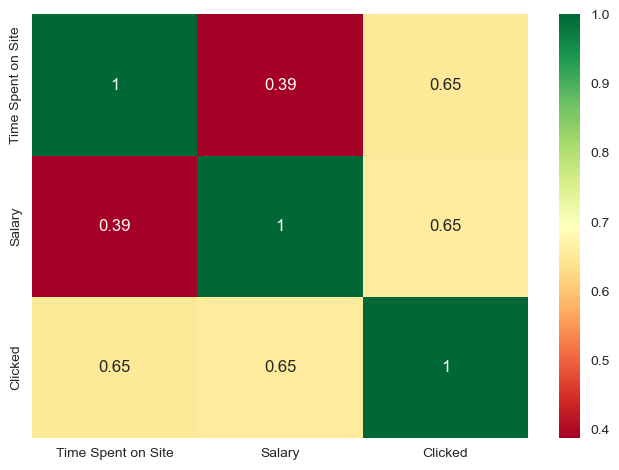

In [686]:
corrMatrix = df.corr(numeric_only=True)
sns.heatmap(corrMatrix,cmap="RdYlGn", annot=True)
plt.show()

In [687]:
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k - 1)*(r - 1)) / (n - 1))
    rcorr = r - ((r - 1)**2) / (n - 1)
    kcorr = k - ((k - 1)**2) / (n - 1)
    return np.sqrt(phi2corr / min((kcorr - 1), (rcorr - 1)))

In [688]:
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

matrix = pd.DataFrame(
    np.zeros((len(categorical_cols), len(categorical_cols))),
    index=categorical_cols, columns=categorical_cols
)

for col1 in categorical_cols:
    for col2 in categorical_cols:
        matrix.loc[col1, col2] = cramers_v(df[col1], df[col2])

C:\Temp\ipykernel_9748\3477140390.py:10: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(phi2corr / min((kcorr - 1), (rcorr - 1)))
C:\Temp\ipykernel_9748\3477140390.py:10: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(phi2corr / min((kcorr - 1), (rcorr - 1)))
C:\Temp\ipykernel_9748\3477140390.py:10: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(phi2corr / min((kcorr - 1), (rcorr - 1)))
C:\Temp\ipykernel_9748\3477140390.py:10: RuntimeWarning: invalid value encountered in scalar divide
  return np.sqrt(phi2corr / min((kcorr - 1), (rcorr - 1)))
C:\Temp\ipykernel_9748\3477140390.py:10: RuntimeWarning: invalid value encountered in scalar divide
  return np.sqrt(phi2corr / min((kcorr - 1), (rcorr - 1)))


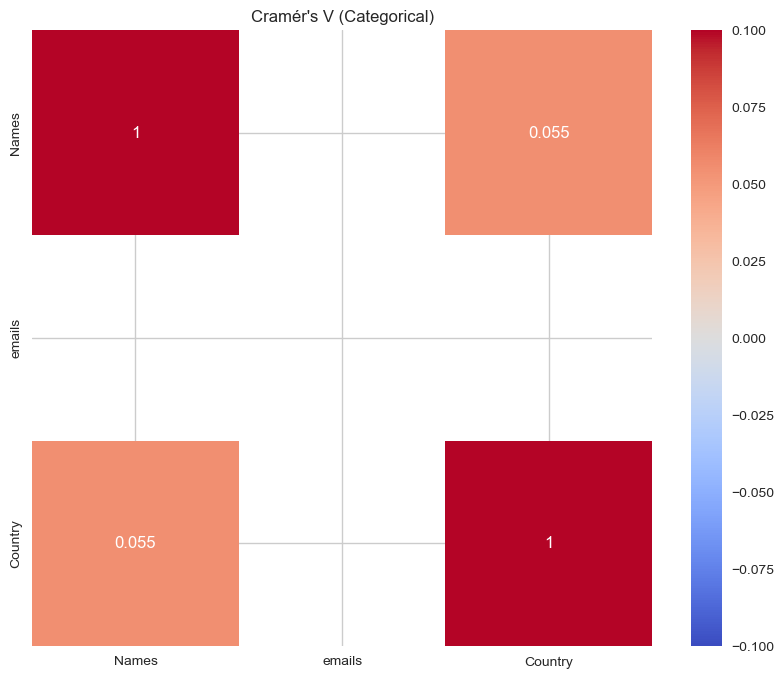

In [689]:
plt.figure(figsize=(10, 8))
sns.heatmap(matrix, annot=True, cmap='coolwarm')
plt.title("Cramér's V (Categorical)")
plt.show()

In [690]:
df['emails'].nunique()

499

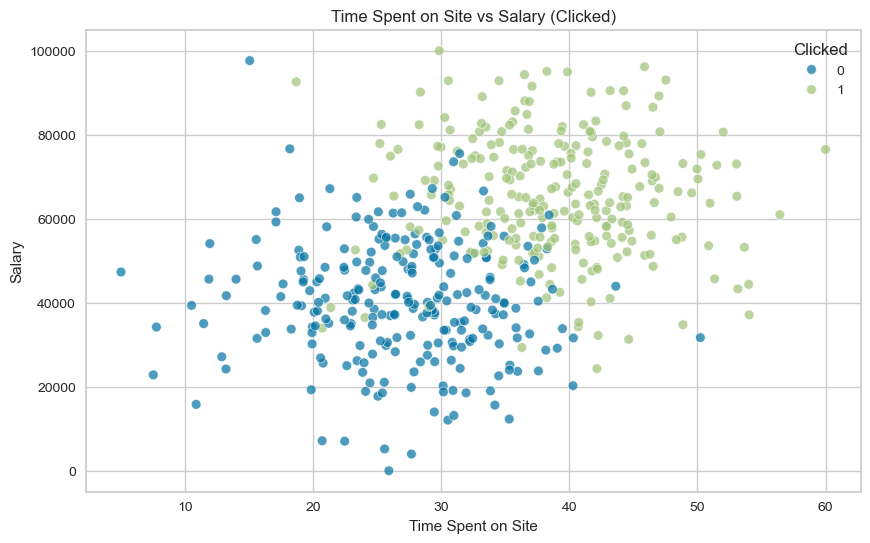

In [691]:
# Scatterplot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Time Spent on Site', y='Salary', hue='Clicked', alpha=0.7)
plt.title('Time Spent on Site vs Salary (Clicked)')
plt.xlabel('Time Spent on Site')
plt.ylabel('Salary')
plt.show()

## Linear model assumptions

In [692]:
X = df.drop(columns='Clicked')
y = df['Clicked']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0, stratify=y
)

In [693]:
X_train.isnull().sum()

Names                 0
emails                0
Country               0
Time Spent on Site    0
Salary                0
dtype: int64

In [694]:
# One-Hot Encoding для Country
X_train_enc = pd.get_dummies(X_train['Country'], drop_first=True, prefix='Country')
X_test_enc  = pd.get_dummies(X_test['Country'],  drop_first=True, prefix='Country')
X_test_enc = X_test_enc.reindex(columns=X_train_enc.columns, fill_value=0) #чтоб столбцы были одинаковые

In [695]:
#Масштабирование числовых признаков
num_feats = ['Time Spent on Site', 'Salary']
scaler = StandardScaler().fit(X_train[num_feats])
X_train_num = scaler.transform(X_train[num_feats])
X_test_num  = scaler.transform(X_test[num_feats])

In [696]:
X_train_proc = np.hstack([X_train_num, X_train_enc.values])
X_test_proc = np.hstack([X_test_num,  X_test_enc.values])

logreg = LogisticRegression()
logreg.fit(X_train_proc, y_train)

LogisticRegression()

In [697]:
# Предсказываем и считаем результаты
pred_train = logreg.predict(X_train_proc)
pred_test = logreg.predict(X_test_proc)

print("Accuracy Train:", accuracy_score(y_train, pred_train))
print("Accuracy Test:", accuracy_score(y_test, pred_test))
print("Precision Train:", precision_score(y_train, pred_train))
print("Precision Test:", precision_score(y_test, pred_test))

Accuracy Train: 0.9512893982808023
Accuracy Test: 0.8866666666666667
Precision Train: 0.9488636363636364
Precision Test: 0.8536585365853658


In [698]:
from sklearn.metrics import log_loss

y_pred_proba = logreg.predict_proba(X_test_proc)[:, 1]
loss = log_loss(y_test, y_pred_proba)
print("Log Loss:", loss)

Log Loss: 0.2812461229363055


In [699]:
print(confusion_matrix(y_test, pred_test))

[[63 12]
 [ 5 70]]


In [700]:
y_train_proba = logreg.predict_proba(X_train_proc)[:, 1]

# Остатки: разница между реальным классом и вероятностью
residuals = y_train - y_train_proba

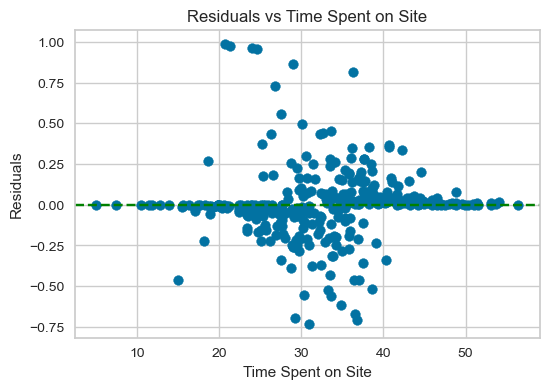

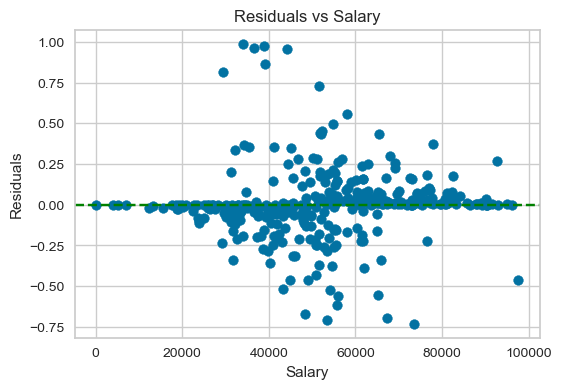

In [701]:
# Time Spent on Site
plt.figure(figsize=(6, 4))
plt.scatter(X_train['Time Spent on Site'], residuals)
plt.axhline(0, linestyle='--', color='green')
plt.xlabel("Time Spent on Site")
plt.ylabel("Residuals")
plt.title("Residuals vs Time Spent on Site")
plt.show()

# Salary
plt.figure(figsize=(6, 4))
plt.scatter(X_train['Salary'], residuals)
plt.axhline(0, linestyle='--', color='green')
plt.xlabel("Salary")
plt.ylabel("Residuals")
plt.title("Residuals vs Salary")
plt.show()

#### Распределение остатков
Остатки равномерно распределены вокруг нуля по всей шкале на первом и втором графике
Нет тренда вверх или вниз.

Гомоскедастичность
Ширина рассеяния остатков остаётся примерно одинаковой вдоль всей оси X.
Нет расширения/сжатия → это говорит (постоянной дисперсии ошибок).

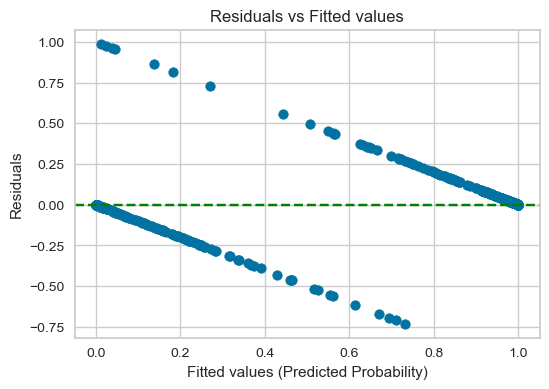

In [702]:
plt.figure(figsize=(6, 4))
plt.scatter(y_train_proba, residuals)
plt.axhline(0, linestyle='--', color='green')
plt.xlabel("Fitted values (Predicted Probability)")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted values")
plt.show()

#### Остатки линейно убывают по мере роста вероятности для обеих ветвей:
верхняя ветвь идёт от 1 к 0
нижняя — от 0 к 1
Остатки распределены симметрично относительно 0.

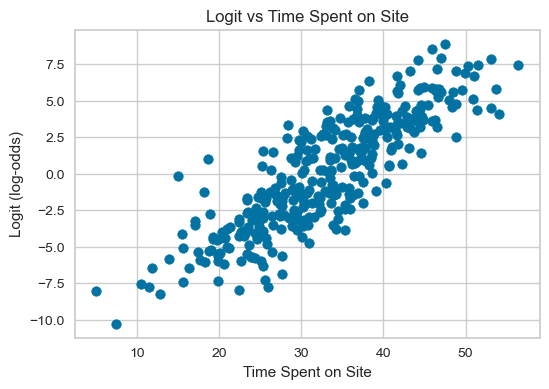

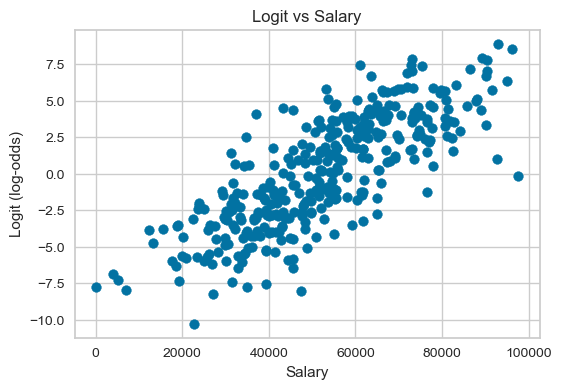

In [703]:
from scipy.special import logit

# Безопасный logit: избегаем деления на 0
logit_vals = logit(np.clip(y_train_proba, 1e-5, 1 - 1e-5))

# Logit vs Time Spent on Site
plt.figure(figsize=(6, 4))
plt.scatter(X_train['Time Spent on Site'], logit_vals)
plt.xlabel("Time Spent on Site")
plt.ylabel("Logit (log-odds)")
plt.title("Logit vs Time Spent on Site")
plt.grid(True)
plt.show()

# Logit vs Salary
plt.figure(figsize=(6, 4))
plt.scatter(X_train['Salary'], logit_vals)
plt.xlabel("Salary")
plt.ylabel("Logit (log-odds)")
plt.title("Logit vs Salary")
plt.grid(True)
plt.show()

Точки идут плотной группой вдоль восходящей линии, распределение точек симметрично и без отклонений от линейности.
Вероятности покрывают практически весь диапазон от 0 до 1,
незначительный шум в точках не нарушает общей закономерности.
### Общий вывод:
Проведённый анализ графиков остатков и логит-функций подтверждает, что признаки Time Spent on Site и Salary находятся в линейной зависимости с логарифмом отношения шансов (log-odds) целевой переменной. Таким образом, структура зависимостей в датасете может быть описана линейной моделью, и задача классификации имеет преимущественно линейную природу.

## Outliers

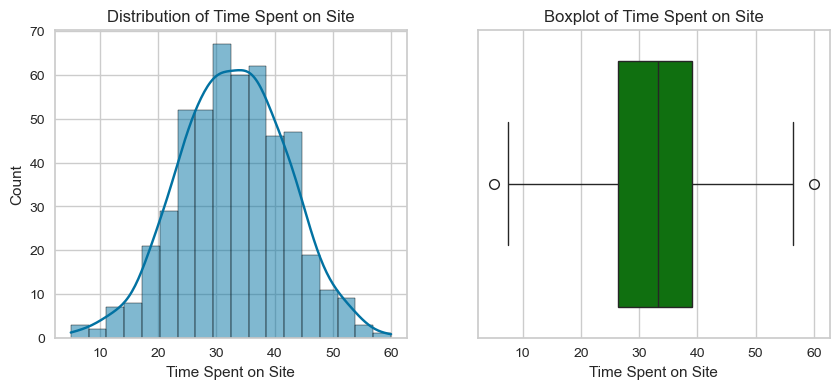

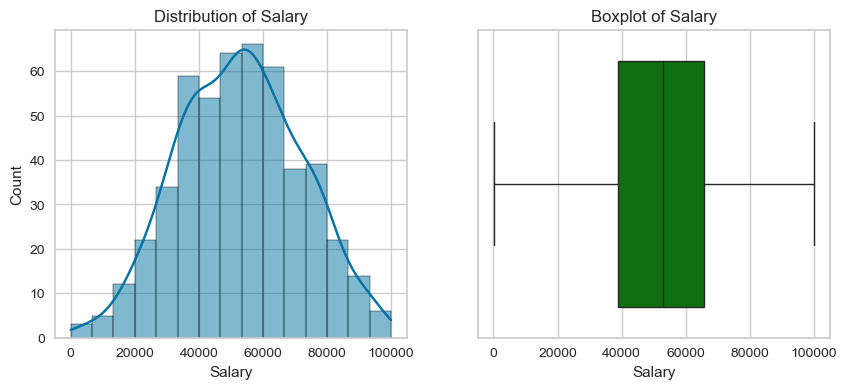

In [704]:
cols_to_look = ['Time Spent on Site', 'Salary']
for var in cols_to_look:
    plt.figure(figsize=(10, 4))
    
    plt.subplot(1, 2, 1)
    plt.grid(True)
    sns.histplot(x=X[var], kde=True, edgecolor='black')
    plt.title(f'Distribution of {var}')
    
    plt.subplot(1, 2, 2)
    plt.grid(True)
    sns.boxplot(x=X[var], color='green')
    plt.title(f'Boxplot of {var}')

In [705]:
IQR = X['Time Spent on Site'].quantile(0.75) - X['Time Spent on Site'].quantile(0.25)
lower_boundary = X['Time Spent on Site'].quantile(0.25) - (IQR * 1.5)
upper_boundary = X['Time Spent on Site'].quantile(0.75) + (IQR * 1.5)
lower_boundary, upper_boundary

(np.float64(7.390117615000008), np.float64(58.14992069499999))

На первом графике(Time spent on site) видно, что время, которое пользователи проводят на сайте, распределено приблизительно нормально, с пиковой плотностью около 30–35 минут. Большинство наблюдений сосредоточено в диапазоне от 20 до 45 минут, причём кривая плотности плавно убывает по краям. Очень короткие сессии (< 10 мин) и очень длинные (> 55 мин) встречаются крайне редко.

В целом: пользователи обычно проводят на сайте полчаса, с небольшим разбросом ±10–15 минут, и лишь единицы заходят на несколько минут или остаются более часа.

На втором графике (Salary)зарплаты распределены почти симметрично вокруг 55 000, с небольшим разбросом ±15 000 – 20 000, аутлаеров не наблюдается.

## Feature engeeniring

In [706]:
X = df.drop('Clicked', axis=1)
y = df['Clicked']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=0)

#### Категориальную переменную Country выбираем top-10самых часто встречающихся стран, остальные в other

In [707]:
# top-10 стран по частоте в X_train
top10 = X_train['Country'].value_counts().nlargest(10).index.tolist()

# Добавим новую колонку Country_top10
X_train['Country_top10'] = X_train['Country'].where(X_train['Country'].isin(top10), other='Other')
X_test['Country_top10'] = X_test['Country'].where(X_test['Country'].isin(top10), other='Other')

# Теперь кодируем эту колонку через OneHotEncoder
cat_col = ['Country_top10']
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

X_train_ohe = pd.DataFrame(
    ohe.fit_transform(X_train[cat_col]),
    columns=ohe.get_feature_names_out(cat_col),
    index=X_train.index
)

X_test_ohe = pd.DataFrame(
    ohe.transform(X_test[cat_col]),
    columns=ohe.get_feature_names_out(cat_col),
    index=X_test.index
)

In [708]:
X_train

,Names,emails,Country,Time Spent on Site,Salary,Country_top10
414,Penelope,vestibulum@metus.org,Luxembourg,35.932737,31644.00077,Other
247,MacKenzie O. Fowler,Aliquam.nec.enim@nec.co.uk,Saint Barthélemy,53.153079,43293.50716,Saint Barthélemy
329,"Langley, Skyler J.",mi.eleifend.egestas@cursuset.net,Austria,32.455176,31531.12364,Other
199,Jelani F. Pace,Morbi@atarcuVestibulum.co.uk,Saint Barthélemy,22.400546,48432.02860,Saint Barthélemy
106,Tanner Ward,diam@orciUt.ca,Togo,25.910277,20.00000,Other
...,...,...,...,...,...,...
497,Pearl,penatibus.et@massanonante.com,Philippines,26.539170,31708.57054,Other
477,Isabella,et.magnis@necmetus.ca,Turkey,25.087617,61653.38311,Other
20,Blythe Romero,Sed.eu@risusNuncac.co.uk,Sudan,17.103576,61661.76519,Other
185,August Duncan,tempor.bibendum@Nuncpulvinar.co.uk,Saint Martin,33.646865,32293.74616,Other


## Feature Selection with mutual information

In [709]:
num_features = ['Time Spent on Site', 'Salary']
country_ohe_cols = [col for col in X_train.columns if col.startswith('Country_top10_')] # Ищем все колонки, начинающиеся с 'Country_top10_'

# Объединяем
final_features = num_features + country_ohe_cols
X_train_enc = X_train[final_features]
X_test_enc = X_test[final_features]

# Mutual Information
k = 3
selector = SelectKBest(mutual_info_classif, k=k)
selector.fit(X_train_enc, y_train)

selected_features = X_train_enc.columns[selector.get_support()]
print("Отобранные признаки:", list(selected_features))

# MI для каждого признака
mi_scores = pd.Series(selector.scores_, index=X_train_enc.columns)
print("\nMutual Information scores (по убыванию):")
print(mi_scores.sort_values(ascending=False))

# Оставляем только лучшие признаки
X_train_sel = selector.transform(X_train_enc)
X_test_sel = selector.transform(X_test_enc)

# Модель и оценка
clf = RandomForestClassifier(random_state=0)
clf.fit(X_train_sel, y_train)
train_pred = clf.predict(X_train_sel)
test_pred = clf.predict(X_test_sel)

print(f"\nAccuracy на трейне: {accuracy_score(y_train, train_pred):.4f}")
print(f"Accuracy на тесте: {accuracy_score(y_test,  test_pred):.4f}")

Отобранные признаки: ['Time Spent on Site', 'Salary']

Mutual Information scores (по убыванию):
Time Spent on Site    0.265329
Salary                0.254849
dtype: float64

Accuracy на трейне: 1.0000
Accuracy на тесте: 0.8800


C:\anaconda3\envs\KV-AI-JLR-12\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:783: UserWarning: k=3 is greater than n_features=2. All the features will be returned.
  warnings.warn(


In [710]:
 #Предсказания и вероятности на трейне
y_pred_train = clf.predict(X_train_sel)
y_proba_train = clf.predict_proba(X_train_sel)[:, 1]

print("Train Metrics")
print(classification_report(y_train, y_pred_train, target_names=['Не кликнул','Кликнул']))
print("ROC‑AUC (Train):", roc_auc_score(y_train, y_proba_train))
print("Confusion Matrix (Train):")
print(confusion_matrix(y_train, y_pred_train))


# Предсказания и вероятности на тесте
y_pred_test = clf.predict(X_test_sel)
y_proba_test = clf.predict_proba(X_test_sel)[:, 1]

print("Test Metrics")
print(classification_report(y_test, y_pred_test, target_names=['Не кликнул','Кликнул']))
print("ROC‑AUC (Test):", roc_auc_score(y_test, y_proba_test))
print("Confusion Matrix (Test):")
print(confusion_matrix(y_test, y_pred_test))

Train Metrics
              precision    recall  f1-score   support

  Не кликнул       1.00      1.00      1.00       174
     Кликнул       1.00      1.00      1.00       175

    accuracy                           1.00       349
   macro avg       1.00      1.00      1.00       349
weighted avg       1.00      1.00      1.00       349

ROC‑AUC (Train): 1.0
Confusion Matrix (Train):
[[174   0]
 [  0 175]]
Test Metrics
              precision    recall  f1-score   support

  Не кликнул       0.89      0.87      0.88        75
     Кликнул       0.87      0.89      0.88        75

    accuracy                           0.88       150
   macro avg       0.88      0.88      0.88       150
weighted avg       0.88      0.88      0.88       150

ROC‑AUC (Test): 0.9340444444444443
Confusion Matrix (Test):
[[65 10]
 [ 8 67]]


## Pipeline and models

In [711]:
df = df.drop(columns=['Names', 'emails'])
X = df.drop(columns='Clicked')
y = df['Clicked']

In [712]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0, stratify=y)
X_train.shape, X_test.shape

((349, 3), (150, 3))

In [713]:
top_10_countries = X_train['Country'].value_counts().head(10).index.tolist()

In [714]:
X_train['Country_top10'] = X_train['Country'].apply(lambda x: x if x in top_10_countries else 'Other')
X_test['Country_top10'] = X_test['Country'].apply(lambda x: x if x in top_10_countries else 'Other')

In [715]:
#признаки
num_features = ['Time Spent on Site', 'Salary']
cat_features = ['Country_top10']

# Преобразователь
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features)
])

# Модели и сетки параметров
models_and_params = {'LassoLogReg':(LogisticRegression
                                    (penalty='l1', solver='liblinear', class_weight='balanced', max_iter=1000, random_state=0), 
                                    {'lassologreg__C': [0.01, 0.1, 1.0, 10.0]}
                                   ),
                     'RandomForest':(RandomForestClassifier
                                    (random_state=0, class_weight='balanced'),
                                    {'randomforest__n_estimators': [50, 100],'randomforest__max_depth': [3, 5, 7]}
                                    ),
                     'XGBoost':(XGBClassifier
                                 (eval_metric='logloss', random_state=0),
                                 {'xgboost__n_estimators': [30, 50, 100],
                                  'xgboost__max_depth': [3, 5, 7],
                                  'xgboost__learning_rate': [0.01, 0.1]}
                                ),
                     'SVC':(SVC(probability=True, kernel='linear', random_state=0),
                            {'svc__C': [0.1, 1.0, 10.0]}
                           ),
                     'NaiveBayes': (GaussianNB(),{})}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
best_estimators = {}

for name, (model, params) in models_and_params.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        (name.lower(), model)
    ])
    grid = GridSearchCV(pipe, param_grid=params, cv=cv, scoring='accuracy',
                        n_jobs=1, error_score=np.nan)
    grid.fit(X_train, y_train)
    best_estimators[name] = grid.best_estimator_

In [716]:
# Сбор метрик
metrics = ['accuracy','precision', 'recall', 'f1', 'roc_auc']
scores = {m: {'train': [], 'test': []} for m in metrics} #словари
names = []

for name, est in best_estimators.items():
    est.fit(X_train, y_train)
    y_pred_tr = est.predict(X_train)
    y_pred_te = est.predict(X_test)
    if hasattr(est, "predict_proba"):
        p_tr = est.predict_proba(X_train)[:, 1]
        p_te = est.predict_proba(X_test)[:, 1]
    else:
        p_tr = est.decision_function(X_train)
        p_te = est.decision_function(X_test)
        
    scores['accuracy']['train'].append(accuracy_score(y_train, y_pred_tr))
    scores['accuracy']['test'].append(accuracy_score(y_test, y_pred_te))
    scores['precision']['train'].append(precision_score(y_train, y_pred_tr))
    scores['precision']['test'].append(precision_score(y_test, y_pred_te))
    scores['recall']['train'].append(recall_score(y_train, y_pred_tr))
    scores['recall']['test'].append(recall_score(y_test, y_pred_te))
    scores['f1']['train'].append(f1_score(y_train, y_pred_tr))
    scores['f1']['test'].append(f1_score(y_test, y_pred_te))
    scores['roc_auc']['train'].append(roc_auc_score(y_train, p_tr))
    scores['roc_auc']['test'].append(roc_auc_score(y_test, p_te))

    names.append(name)

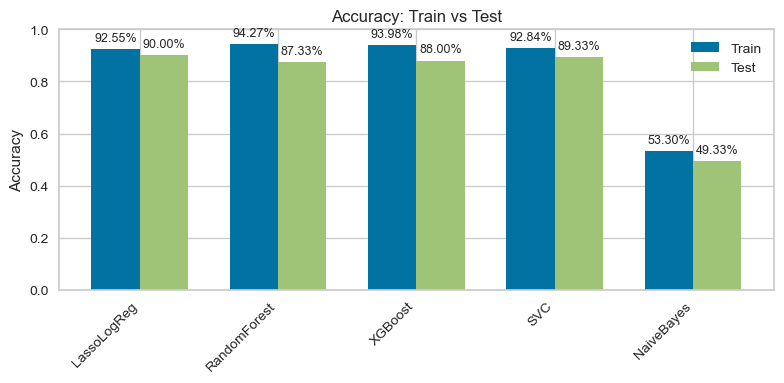

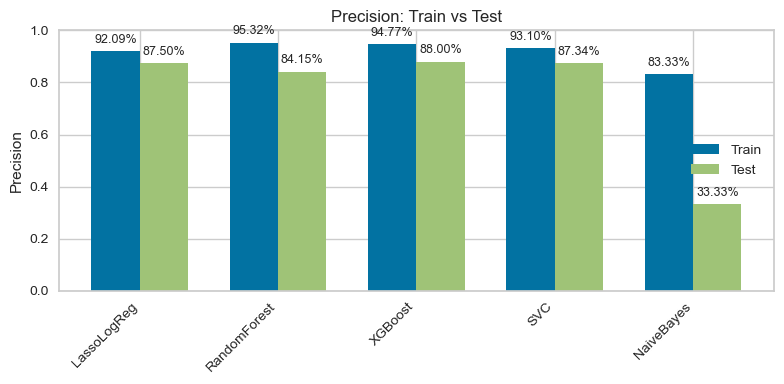

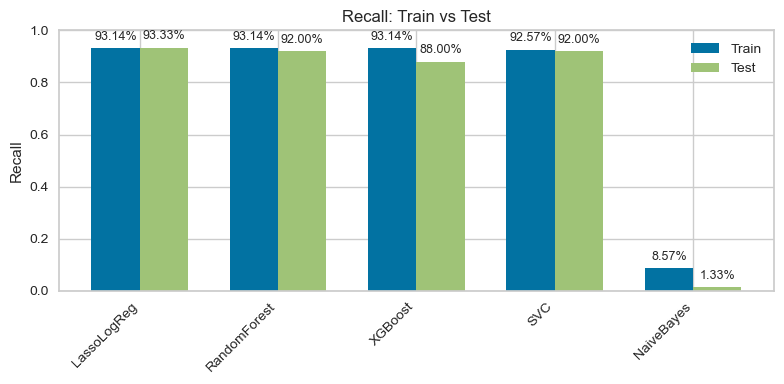

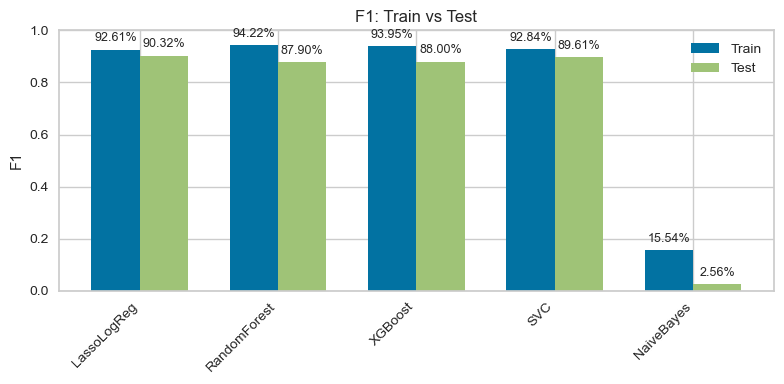

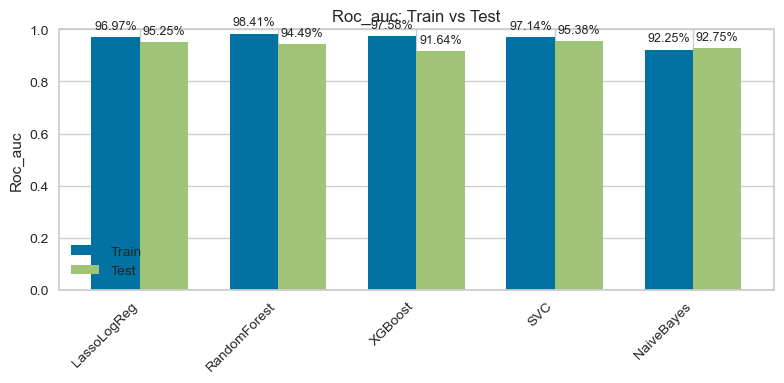

In [717]:
# Визуализация

for metric in metrics:
    plt.figure(figsize=(8, 4))
    idx = np.arange(len(names))
    w = 0.35

    bars_tr = plt.bar(idx - w/2, scores[metric]['train'], w)
    bars_te = plt.bar(idx + w/2, scores[metric]['test'], w)

    plt.xticks(idx, names, rotation=45, ha='right')
    plt.ylim(0, 1)
    plt.ylabel(metric.capitalize())
    plt.title(f'{metric.capitalize()}: Train vs Test')
    plt.legend(['Train', 'Test'])

    # добавляем проценты
    for bar in bars_tr + bars_te:
        h = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, h + 0.02,
                 f'{h:.2%}', ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.show()


 LassoLogReg — Classification Report (Train) 
              precision    recall  f1-score   support

           0     0.9302    0.9195    0.9249       174
           1     0.9209    0.9314    0.9261       175

    accuracy                         0.9255       349
   macro avg     0.9256    0.9255    0.9255       349
weighted avg     0.9256    0.9255    0.9255       349

 LassoLogReg — Classification Report (Test) 
              precision    recall  f1-score   support

           0     0.9286    0.8667    0.8966        75
           1     0.8750    0.9333    0.9032        75

    accuracy                         0.9000       150
   macro avg     0.9018    0.9000    0.8999       150
weighted avg     0.9018    0.9000    0.8999       150



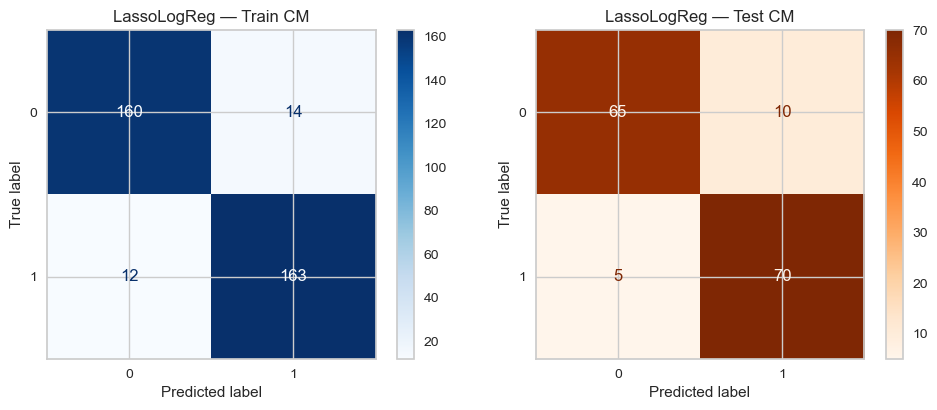


 RandomForest — Classification Report (Train) 
              precision    recall  f1-score   support

           0     0.9326    0.9540    0.9432       174
           1     0.9532    0.9314    0.9422       175

    accuracy                         0.9427       349
   macro avg     0.9429    0.9427    0.9427       349
weighted avg     0.9429    0.9427    0.9427       349

 RandomForest — Classification Report (Test) 
              precision    recall  f1-score   support

           0     0.9118    0.8267    0.8671        75
           1     0.8415    0.9200    0.8790        75

    accuracy                         0.8733       150
   macro avg     0.8766    0.8733    0.8731       150
weighted avg     0.8766    0.8733    0.8731       150



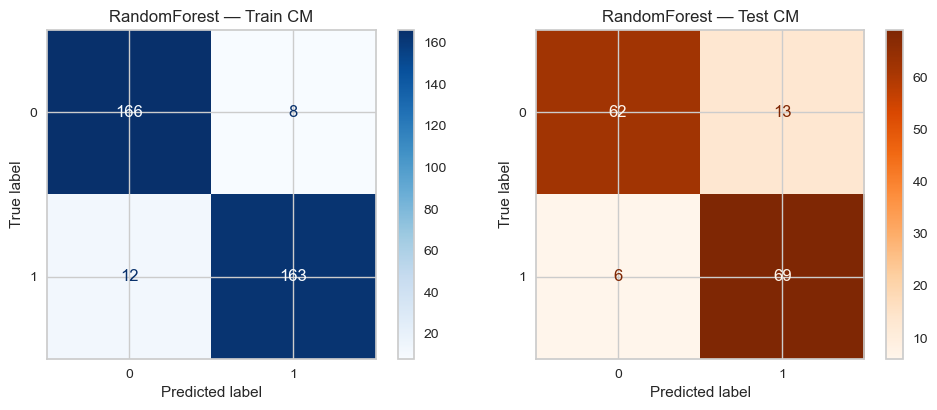


 XGBoost — Classification Report (Train) 
              precision    recall  f1-score   support

           0     0.9322    0.9483    0.9402       174
           1     0.9477    0.9314    0.9395       175

    accuracy                         0.9398       349
   macro avg     0.9399    0.9399    0.9398       349
weighted avg     0.9400    0.9398    0.9398       349

 XGBoost — Classification Report (Test) 
              precision    recall  f1-score   support

           0     0.8800    0.8800    0.8800        75
           1     0.8800    0.8800    0.8800        75

    accuracy                         0.8800       150
   macro avg     0.8800    0.8800    0.8800       150
weighted avg     0.8800    0.8800    0.8800       150



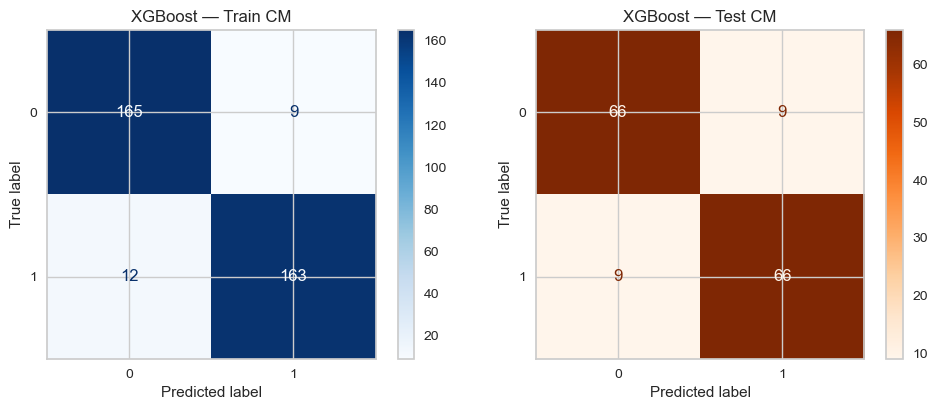


 SVC — Classification Report (Train) 
              precision    recall  f1-score   support

           0     0.9257    0.9310    0.9284       174
           1     0.9310    0.9257    0.9284       175

    accuracy                         0.9284       349
   macro avg     0.9284    0.9284    0.9284       349
weighted avg     0.9284    0.9284    0.9284       349

 SVC — Classification Report (Test) 
              precision    recall  f1-score   support

           0     0.9155    0.8667    0.8904        75
           1     0.8734    0.9200    0.8961        75

    accuracy                         0.8933       150
   macro avg     0.8945    0.8933    0.8933       150
weighted avg     0.8945    0.8933    0.8933       150



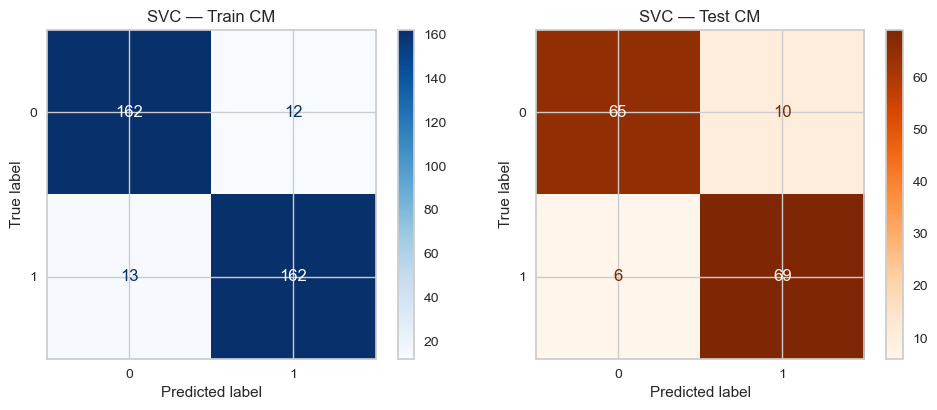


 NaiveBayes — Classification Report (Train) 
              precision    recall  f1-score   support

           0     0.5166    0.9828    0.6772       174
           1     0.8333    0.0857    0.1554       175

    accuracy                         0.5330       349
   macro avg     0.6750    0.5342    0.4163       349
weighted avg     0.6754    0.5330    0.4156       349

 NaiveBayes — Classification Report (Test) 
              precision    recall  f1-score   support

           0     0.4966    0.9733    0.6577        75
           1     0.3333    0.0133    0.0256        75

    accuracy                         0.4933       150
   macro avg     0.4150    0.4933    0.3416       150
weighted avg     0.4150    0.4933    0.3416       150



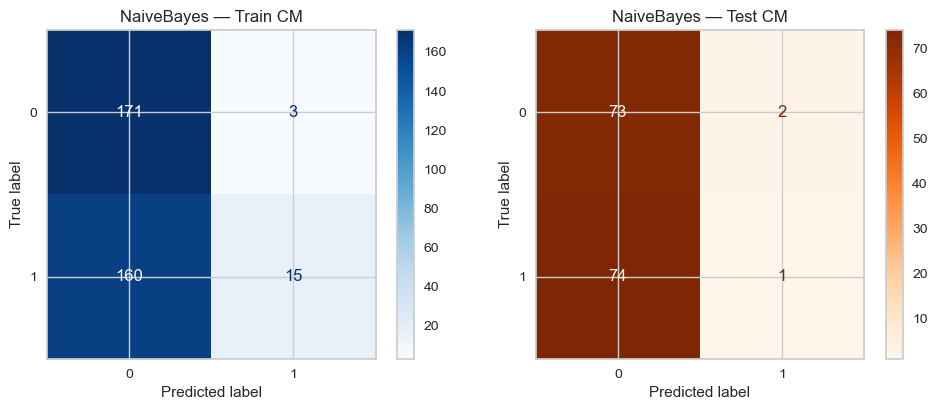

In [718]:
# Confusion Matrix и Classification Report

for name, est in best_estimators.items():

    # Предсказания
    y_pred_tr = est.predict(X_train)
    y_pred_te = est.predict(X_test)

    # Classification report
    print(f"\n {name} — Classification Report (Train) ")
    print(classification_report(y_train, y_pred_tr, digits=4))
    print(f" {name} — Classification Report (Test) ")
    print(classification_report(y_test, y_pred_te, digits=4))

    # Confusion matrix
    cm_tr = confusion_matrix(y_train, y_pred_tr)
    cm_te = confusion_matrix(y_test, y_pred_te)

    disp_tr = ConfusionMatrixDisplay(cm_tr, display_labels=est.classes_)
    disp_te = ConfusionMatrixDisplay(cm_te, display_labels=est.classes_)

    # Рисуем на отдельных фигурах
    fig, ax = plt.subplots(1, 2, figsize=(10, 4))
    disp_tr.plot(ax=ax[0], cmap='Blues', values_format='d')
    ax[0].set_title(f"{name} — Train CM")

    disp_te.plot(ax=ax[1], cmap='Oranges', values_format='d')
    ax[1].set_title(f"{name} — Test CM")

    plt.tight_layout()
    plt.show()